# Advanced spatial joins

## Lecture objectives

1. Explore different spatial relationships (predicates)
2. Practice troubleshooting spatial joins

## Other types of spatial relationships

The `intersects` operator, which we used in the previous lecture, is one of the most common spatial predicates, i.e. the relationship between two geometries. It is excellent if you want to know whether a point is within (or on the boundary) of a polygon. In general, each point will match to one polygon, but you need to be careful if your points are on the boundary and thus intersect with two polygons.

Let's start by loading two of the datasets we used in the last lecture. This is exactly the same code.

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import pygris

pantryDf = pd.read_csv('../data/Food_Resources_in_California.csv')
pantryDf = pantryDf[pantryDf.County=='Los Angeles']

# convert to a GeoDataFrame
pantrygdf = gpd.GeoDataFrame(
    pantryDf, geometry=gpd.points_from_xy(pantryDf.Longitude, pantryDf.Latitude, 
                                          crs='EPSG:4326'))
# convert to 3857, so we can match the contextily default for basemaps
pantrygdf.to_crs('EPSG:3857', inplace=True)

In [16]:
# get the census data for LA County
# B19019_001E is median household income
r = requests.get('https://api.census.gov/data/2019/acs/acs5?get=B19019_001E&for=tract:*&in=state:06%20county:037')
censusdata = r.json()
incomeDf = pd.DataFrame(censusdata[1:], columns=censusdata[0])
incomeDf.rename(columns={'B19019_001E':'median_HH_income'}, inplace=True)
incomeDf.median_HH_income = incomeDf.median_HH_income.astype(int)
incomeDf.loc[incomeDf.median_HH_income<0, 'median_HH_income'] = np.nan

In [36]:
tracts = gpd.read_file("/Users/Tomo/Desktop/UP213/Week4/tl_2024_06_tract.zip")  

In [37]:
tracts.set_index(['STATEFP','COUNTYFP','TRACTCE'], inplace=True)
tracts.index.names=['state','county','tract']
tracts = tracts[tracts.index.get_level_values('county') == '037']

In [38]:
# Add the tract boundaries. For this, we'll use the pygris package
#tracts = pygris.tracts(state='06',county='037', year=2019)
#tracts.set_index(['STATEFP','COUNTYFP','TRACTCE'], inplace=True)
#tracts.index.names=['state','county','tract']
# and join the tract boundaries to the census data
incomeDf = tracts[['geometry']].join(incomeDf.set_index(['state','county','tract'])).reset_index()

# create a consolidated GEOID column
incomeDf['GEOID'] = incomeDf.state+incomeDf.county+incomeDf.tract

# reproject to the same crs as pantrygdf
incomeDf = incomeDf.to_crs('EPSG:3857')

Different predicates are defined in the `shapely` [documentation](https://shapely.readthedocs.io/en/stable/manual.html#binary-predicates). (`shapely` is working behind the scenes for many `geopandas` operations.)

In [7]:
print(incomeDf.sindex.valid_query_predicates)

{None, 'touches', 'contains_properly', 'covered_by', 'intersects', 'contains', 'covers', 'crosses', 'within', 'dwithin', 'overlaps'}


Let's look at the number of rows that are produced with three different predicates: intersects, contains, and within.

How do you explain the different results below?

In [39]:
print('There are {} pantries and {} tracts.'.format(len(pantrygdf), len(incomeDf)))

pantries_intersects = gpd.sjoin(incomeDf[['GEOID','geometry']], 
                           pantrygdf, how="inner", predicate='intersects')
print('Using intersects: {} rows'.format(len(pantries_intersects)))

pantries_contains = gpd.sjoin(incomeDf[['GEOID','geometry']], 
                           pantrygdf, how="inner", predicate='contains')
print('Using contains: {} rows'.format(len(pantries_contains)))

pantries_within = gpd.sjoin(incomeDf[['GEOID','geometry']], 
                           pantrygdf, how="inner", predicate='within')
print('Using within: {} rows'.format(len(pantries_within)))

#census tractというpolygonがpantryというpointの中に入ることはできないので、3つめは0になる

There are 211 pantries and 2498 tracts.
Using intersects: 209 rows
Using contains: 209 rows
Using within: 0 rows


Intersects and contains return the same number of rows. If a census tract (a polygon) intersects a pantry (a point geometry), it also contains it.

But a census tract is not within a pantry. A polygon cannot be within a point (it's too big!) 

## Troubleshooting spatial joins

Also note that we have fewer join results than pantries. Why? A good guess would be that some pantries are physically outside the county (the "county" field notwithstanding).

<div class="alert alert-block alert-info">
<strong>Thought exercise:</strong> How would you verify that the missing pantries are outside the county?
</div>

We could map them. But note that the pantries dataset has a County field. So let's do `groupby` and ask for the size of each group. (All of the rows should be Los Angeles county because we filtered when we loaded in the dataset, but maybe we made a mistake?)

In [40]:
pantrygdf.groupby('County').size()

County
Los Angeles    211
dtype: int64

Hmm. So either all the pantries are within the county, or there is an error in the `County` column. Or our join is going wrong.

Let's map it and take a look. Note that we use the `alpha` parameter to adjust the transparency of both the census tracts and the basemap, making it easier to see the intersection.

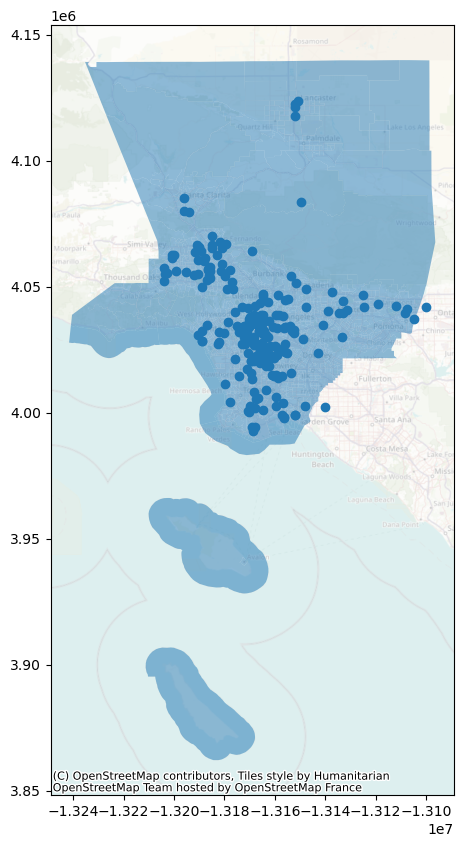

In [41]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10,10)) #まず空白のキャンバスを用意
pantrygdf.plot(ax=ax) #pantryのplotをする
incomeDf.plot(ax=ax, alpha=0.5) # 50% opacity
ctx.add_basemap(ax=ax, alpha=0.3) # 30% opacity

Aha. It looks like two of them are just outside the boundary. Probably, the `County` field was misspecified, or the location is imprecise. 

Let's look at the culprits. The `difference` function, which works on a pandas `Index`, is useful here. It's a set-theoretic operation, which looks for the elements that are in one index but not other. [Read about it here.](https://pandas.pydata.org/docs/reference/api/pandas.Index.difference.html)

In [42]:
pantrygdf.index.difference(pantries_intersects.index)
#2つ出てきてほしいのに202も結果が出てきた
#よく考えてみると、pantrygdfとpantries_intersectsは全く別のindex（pantries_intersectsはincomeDfのindexを使っている）

Index([315, 330, 331, 332, 333, 334, 336, 337, 338, 339,
       ...
       531, 532, 533, 534, 535, 536, 537, 538, 539, 540],
      dtype='int64', length=202)

OK, something went wrong. We should expect two rows (211 in `pantrygdf`, minus 209 in `pantries_intersects`).

In [43]:
pantries_intersects.head(2)

,GEOID,geometry,index_right,Name,Street Address,City,State,Zip Code,County,Phone,Description,Resource Type,Web Link,Notes,Latitude,Longitude
5,06037206050,"POLYGON ((-13161157.317 4034382.048, -13161124...",430,Latino Equality Alliance: Mi Centro: Pride Pantry,553 S. Clarence St.,Los Angeles,CA,90033,Los Angeles,NaN,RSVP here: bit.ly/LEAPridePantry,Food Pantry,http://bit.ly/LEAPridePantry,NaN,34.039485,-118.223458
6,06037111402,"POLYGON ((-13191619.205 4063483.652, -13191618...",473,Rescue Mission Alliance - Valley Food Bank - V...,10408 Balboa Blvd.,Granda Hills,CA,91344,Los Angeles,(818) 366-0089,The agency provides emergency food for individ...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.259525,-118.502107


Aha. The spatial join created a new index, and put the original index in a column called `index_right`. Let's use this column instead. 

In [44]:
pantrygdf.index.difference(pantries_intersects.index_right)

Index([390, 400], dtype='int64')

What are these rows?

In [45]:
pantrygdf.loc[[390,400]]  

,Name,Street Address,City,State,Zip Code,County,Phone,Description,Resource Type,Web Link,Notes,Latitude,Longitude,geometry
390,Foothill Family Shelter,"1501 W. 9th St., Ste. D",Upland,CA,91786,Los Angeles,(909) 920-0453,The agency provides transitional shelter for h...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,34.096378,-117.679776,POINT (-13100052.741 4041750.59)
400,Grateful Hearts,5420 Katella Ave.,Los Alamitos,CA,90720,Los Angeles,(562) 431-0880,The agency provides emergency food and volunte...,Food Pantry,https://www.211la.org/211search/more?site_id=1...,NaN,33.802645,-118.038262,POINT (-13139959.22 4002332.756)


Well, neither of these two cities are in Los Angeles County. (Upland is in San Bernadino, and Los Alamitos is in Orange.) So it's safe to ignore them, and work with the 209 pantries that were spatially joined.

The point here: spatial joins often throw up unexpected results. You'll have to do some detective work to figure out what goes wrong.

## Spatial attributes
We can access useful attributes of the geometry directly from `geopandas`. Areas, lengths, and bounding boxes are three examples.

Note that the units will be based on your projection. You probably don't want to measure distances or areas in degrees! But even a projection in meters can be distorted.

The best projection will vary locally. In the US, the State Plane coordinate systems are usually the best choice for local-level work. Los Angeles is in State Plane [California zone 5, which has an EPSG code of 3497](https://epsg.io/3497). Note the units are in meters. If you want feet, [try EPSG code 6424](https://epsg.io/6424). 

In [46]:
# in Web Mercator
print(incomeDf.crs)
print(incomeDf.geometry.area.head())

EPSG:3857
0    1.327878e+06
1    4.188154e+05
2    2.139669e+06
3    2.101931e+06
4    1.275901e+06
dtype: float64


In [47]:
# in State Plane
#EPSG:3497というのが、Californiaで面積や長さを測定するのに適したprojection
#結果を見て分かるように、Web Mercator(EPSG:3857)での測定値と大きく異なる
print(incomeDf.to_crs('EPSG:3497').geometry.area.head())

0    9.099873e+05
1    2.869639e+05
2    1.466259e+06
3    1.438684e+06
4    8.735355e+05
dtype: float64


For a polygon, length is the perimeter.

In [48]:
print(incomeDf.geometry.to_crs('EPSG:3497').length.head()) 

0    3900.222960
1    2813.148521
2    6112.608484
3    6421.079926
4    3666.486732
dtype: float64


The projection is less important for the bounding box, as long as you know which one you are using. Here, we are still in Web Mercator. But lat/lon is often the easiest to work with.

In [49]:
print(incomeDf.geometry.bounds.head())

           minx          miny          maxx          maxy
0 -1.315828e+07  4.030528e+06 -1.315701e+07  4.031941e+06
1 -1.316016e+07  4.031609e+06 -1.315891e+07  4.032574e+06
2 -1.316022e+07  4.030497e+06 -1.315823e+07  4.032233e+06
3 -1.316233e+07  4.037036e+06 -1.316069e+07  4.039454e+06
4 -1.316218e+07  4.035918e+06 -1.316088e+07  4.037185e+06


In [50]:
#EPSG:4326はlat,lonで表示する方法
print(incomeDf.to_crs('EPSG:4326').geometry.bounds.head())

         minx       miny        maxx       maxy
0 -118.202837  34.012856 -118.191416  34.023373
1 -118.219711  34.020900 -118.208517  34.028083
2 -118.220238  34.012623 -118.202383  34.025549
3 -118.239236  34.061300 -118.224513  34.079289
4 -118.237887  34.052978 -118.226241  34.062409


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
  <li>Intersects is the most common spatial predicate, but it's not always what you want.</li>
  <li>Use an an appropriate projection.</li>
  <li>As with any join, inspect your output. If it's not what you expect, computing summary statistics or mapping can help identify the problem.</li>
</ul>
</div>